In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
MLPKANresultsnores = pd.read_csv('./parameterTests/MLPKAN_main_nores.csv')
MLPKANresultsrestrainable = pd.read_csv('./parameterTests/MLPKAN_main_restrainable.csv')
MLPKANresultresstaticres = pd.read_csv('./parameterTests/MLPKAN_main_staticres.csv')
efficientKANresults = pd.read_csv('./parameterTests/EfficientKAN_main.csv')
fastKANresults = pd.read_csv('./parameterTests/FastKAN_main.csv')



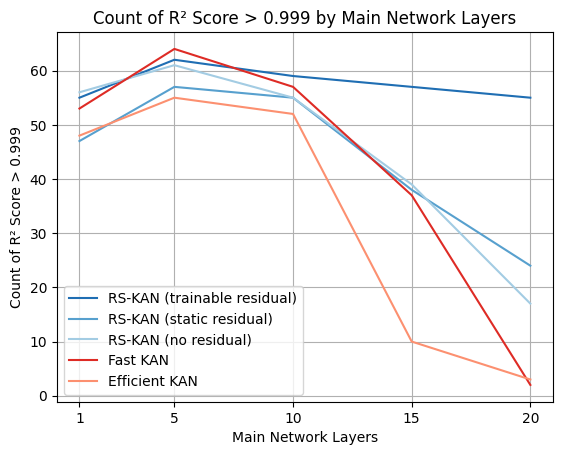

In [15]:
palette = {
    'RS-KAN (trainable residual)': '#1F6EB3',
    'RS-KAN (static residual)': '#57A0CE',
    'RS-KAN (no residual)': '#A3CCE3',
    'FastKAN': '#DE2B25',
    'EfficientKAN': '#FC9070',
}

count99nores = MLPKANresultsnores[MLPKANresultsnores['R2 Score (Test)'] > 0.999].groupby('Main Network Layers').size()
count99restrainable = MLPKANresultsrestrainable[MLPKANresultsrestrainable['R2 Score (Test)'] > 0.999].groupby('Main Network Layers').size()
count99staticres = MLPKANresultresstaticres[MLPKANresultresstaticres['R2 Score (Test)'] > 0.999].groupby('Main Network Layers').size()
count99fast = fastKANresults[fastKANresults['R2 Score (Test)'] > 0.999].groupby('Main Network Layers').size()
count99efficient = efficientKANresults[efficientKANresults['R2 Score (Test)'] > 0.999].groupby('Main Network Layers').size()

plt.plot(count99restrainable.index, count99restrainable.values, color=palette['RS-KAN (trainable residual)'], label='RS-KAN (trainable residual)')
plt.plot(count99staticres.index, count99staticres.values, color=palette['RS-KAN (static residual)'], label='RS-KAN (static residual)')
plt.plot(count99nores.index, count99nores.values, color=palette['RS-KAN (no residual)'], label='RS-KAN (no residual)')
plt.plot(count99fast.index, count99fast.values, color=palette['FastKAN'], label='Fast KAN')
plt.plot(count99efficient.index, count99efficient.values, color=palette['EfficientKAN'], label='Efficient KAN')

plt.xlabel('Main Network Layers')
plt.ylabel('Count of R² Score > 0.999')
plt.title('Count of R² Score > 0.999 by Main Network Layers')
plt.legend()

# Set x-axis ticks to the actual layer values that have data
all_layers = sorted(set(count99nores.index) | set(count99restrainable.index) | set(count99staticres.index) | set(count99efficient.index) | set(count99fast.index))
plt.xticks(all_layers)

plt.grid()
plt.savefig("./parameterTests/scalability.pdf", bbox_inches="tight", facecolor="white")
plt.show()